In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import zscore

In [ ]:
df = pd.read_csv("C:/Users/preet/Desktop/ML/Datasets/bengaluru_house_prices_bhp.csv")
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [7]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [8]:
df = df.drop(columns=["area_type","society","availability","location"])
df.head()

,size,total_sqft,bath,balcony,price
0,2 BHK,1056,2.0,1.0,39.07
1,4 Bedroom,2600,5.0,3.0,120.00
2,3 BHK,1440,2.0,3.0,62.00
3,3 BHK,1521,3.0,1.0,95.00
4,2 BHK,1200,2.0,1.0,51.00


In [9]:
df.isnull().sum()

size           16
total_sqft      0
bath           73
balcony       609
price           0
dtype: int64

In [10]:
for i in ["bath","balcony"]:
    df[i] = df[i].fillna(0)

In [11]:
df.isnull().sum()

size          16
total_sqft     0
bath           0
balcony        0
price          0
dtype: int64

In [12]:
df = df.dropna()

In [13]:
df.isnull().sum()

size          0
total_sqft    0
bath          0
balcony       0
price         0
dtype: int64

In [ ]:
df[["bhk","a"]] = df["size"].str.split(" ",expand=True)
df.head()

,size,total_sqft,bath,balcony,price,bhk,a
0,2 BHK,1056,2.0,1.0,39.07,2,BHK
1,4 Bedroom,2600,5.0,3.0,120.00,4,Bedroom
2,3 BHK,1440,2.0,3.0,62.00,3,BHK
3,3 BHK,1521,3.0,1.0,95.00,3,BHK
4,2 BHK,1200,2.0,1.0,51.00,2,BHK


In [15]:
df = df.drop(columns=["size","a"])
df.head()

,total_sqft,bath,balcony,price,bhk
0,1056,2.0,1.0,39.07,2
1,2600,5.0,3.0,120.00,4
2,1440,2.0,3.0,62.00,3
3,1521,3.0,1.0,95.00,3
4,1200,2.0,1.0,51.00,2


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13304 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_sqft  13304 non-null  object 
 1   bath        13304 non-null  float64
 2   balcony     13304 non-null  float64
 3   price       13304 non-null  float64
 4   bhk         13304 non-null  object 
dtypes: float64(3), object(2)
memory usage: 623.6+ KB


In [17]:
df["bhk"] = df["bhk"].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13304 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_sqft  13304 non-null  object 
 1   bath        13304 non-null  float64
 2   balcony     13304 non-null  float64
 3   price       13304 non-null  float64
 4   bhk         13304 non-null  int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 623.6+ KB


In [18]:
def convert_sqft_to_num(x):
    # 1. Handle Ranges (e.g., '2100 - 2850')
    tokens = x.split('-')
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    
    # 2. Handle Normal Numbers & Units
    try:
        # Check for specific units and convert to sqft
        if 'Sq. Meter' in x:
            return float(x.replace('Sq. Meter', '')) * 10.764
        elif 'Sq. Yards' in x:
            return float(x.replace('Sq. Yards', '')) * 9.0
        elif 'Acres' in x:
            return float(x.replace('Acres', '')) * 43560
        elif 'Guntha' in x:
            return float(x.replace('Guntha', '')) * 1089
        elif 'Cents' in x:
            return float(x.replace('Cents', '')) * 435.6
        elif 'Grounds' in x:
            return float(x.replace('Grounds', '')) * 2400
        elif 'Perch' in x:
            return float(x.replace('Perch', '')) * 272.25
            
        # If no unit, just convert to float
        return float(x)
    except:
        return None

# Apply the Pro function
df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_num)

In [19]:
df.sample(10)

,total_sqft,bath,balcony,price,bhk
244,1285.0,2.0,3.0,72.50,2
4612,1100.0,2.0,1.0,48.00,2
10434,1400.0,2.0,2.0,40.45,3
12851,1075.0,2.0,2.0,60.00,2
13108,935.0,2.0,1.0,32.72,2
3348,1247.0,2.0,0.0,53.00,2
7618,2002.0,3.0,2.0,120.00,3
5190,4400.0,4.0,1.0,350.00,5
5540,797.0,2.0,1.0,32.00,2
9288,1095.0,2.0,1.0,45.00,2


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13304 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_sqft  13304 non-null  float64
 1   bath        13304 non-null  float64
 2   balcony     13304 non-null  float64
 3   price       13304 non-null  float64
 4   bhk         13304 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 623.6 KB


<Axes: xlabel='total_sqft'>

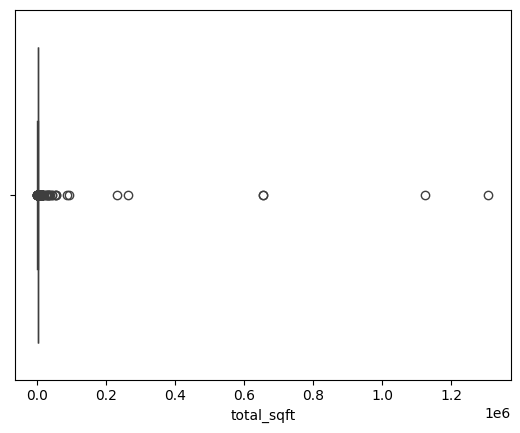

In [21]:
sns.boxplot(df, x= "total_sqft")

In [23]:
Q1 = df['total_sqft'].quantile(0.25)
Q3 = df['total_sqft'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['total_sqft'] >= Q1 - 1.5 * IQR) & (df['total_sqft'] <= Q3 + 1.5 * IQR)]

<Axes: xlabel='total_sqft'>

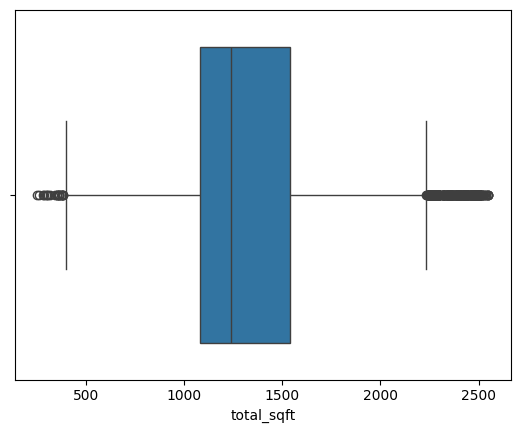

In [24]:
sns.boxplot(df, x= "total_sqft")

<Axes: xlabel='bath'>

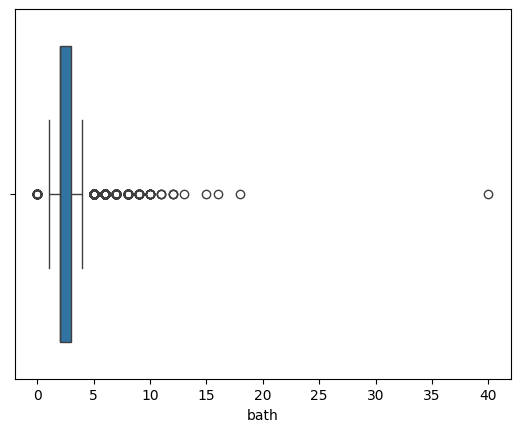

In [25]:
sns.boxplot(df, x= "bath")

In [26]:
Q1 = df['bath'].quantile(0.25)
Q3 = df['bath'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['bath'] >= Q1 - 1.5 * IQR) & (df['bath'] <= Q3 + 1.5 * IQR)]

<Axes: >

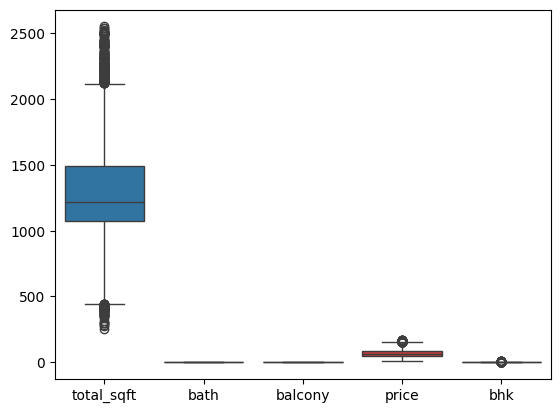

In [ ]:
sns.boxplot(df)

<Axes: xlabel='bath'>

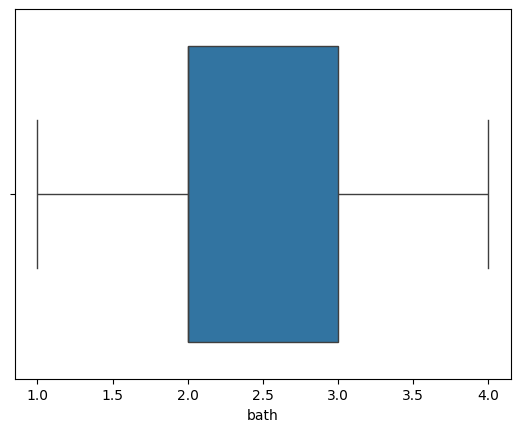

In [27]:
sns.boxplot(df, x= "bath")

<Axes: xlabel='balcony'>

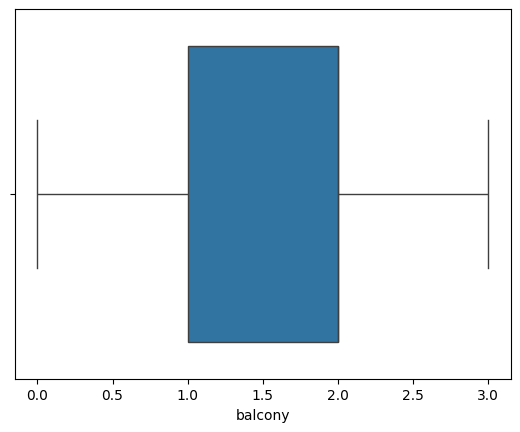

In [28]:
sns.boxplot(df, x= "balcony")

<Axes: xlabel='bhk'>

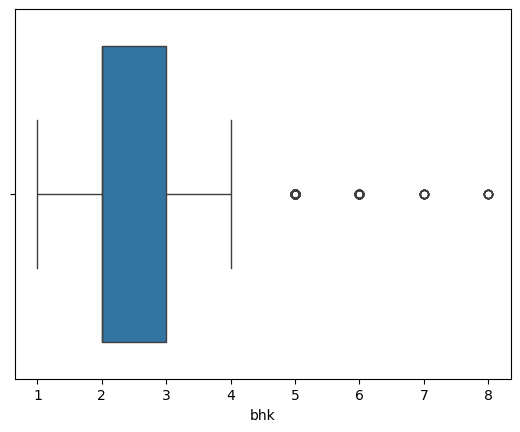

In [29]:
sns.boxplot(df, x= "bhk")

<Axes: xlabel='price'>

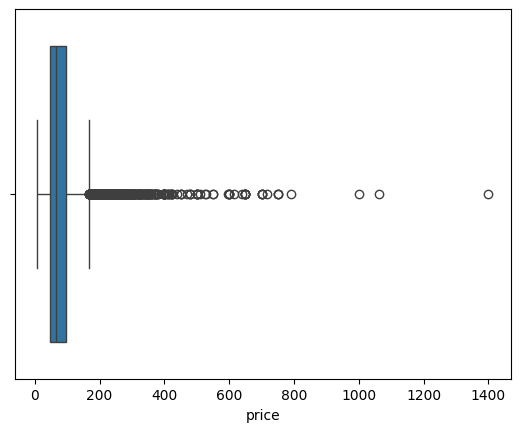

In [30]:
sns.boxplot(df, x= "price")

In [31]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['price'] >= Q1 - 1.5 * IQR) & (df['price'] <= Q3 + 1.5 * IQR)]

<Axes: xlabel='price'>

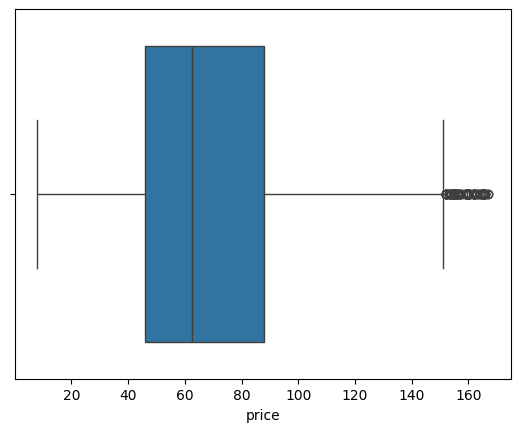

In [32]:
sns.boxplot(df, x= "price")

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10772 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_sqft  10772 non-null  float64
 1   bath        10772 non-null  float64
 2   balcony     10772 non-null  float64
 3   price       10772 non-null  float64
 4   bhk         10772 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 504.9 KB


In [34]:
df.corr()["price"]

total_sqft    0.662869
bath          0.597998
balcony       0.142730
price         1.000000
bhk           0.531838
Name: price, dtype: float64

__Here relation between total_sqrt, bath, bhk vs price is average but balcony vs price is too weak.__

<Axes: xlabel='total_sqft', ylabel='price'>

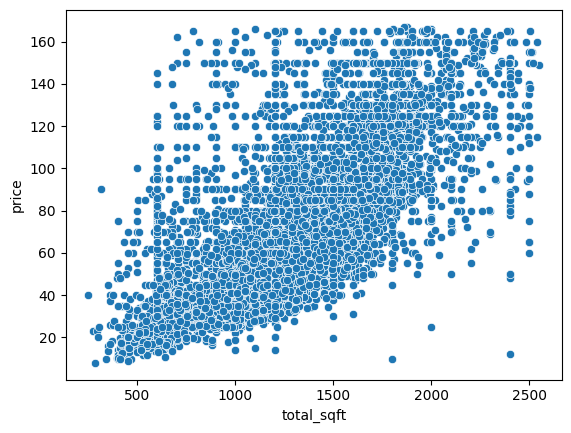

In [35]:
sns.scatterplot(df, x="total_sqft", y="price")

<Axes: xlabel='bath', ylabel='price'>

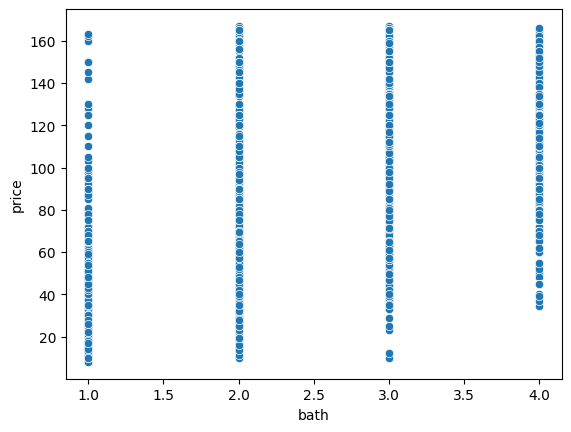

In [36]:
sns.scatterplot(df, x="bath", y="price")

<Axes: xlabel='balcony', ylabel='price'>

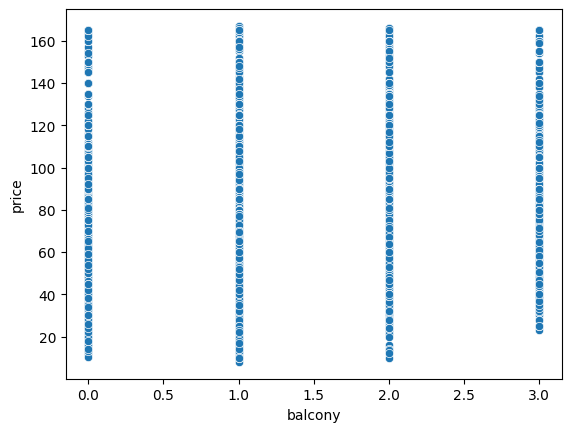

In [37]:
sns.scatterplot(df, x="balcony", y="price")

<Axes: xlabel='bhk', ylabel='price'>

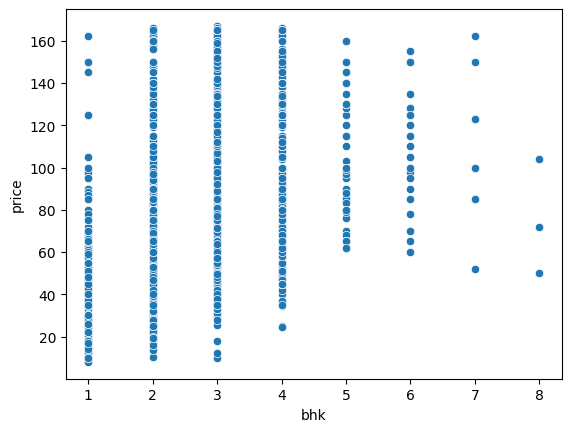

In [38]:
sns.scatterplot(df, x="bhk", y="price")

__Here we can use Linear Regression as relation between all columns and target column is linear.__

In [39]:
x = df.drop(columns = ["price"])
y = df["price"]

In [40]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y, train_size=0.8, random_state=42)

In [41]:
model = LinearRegression()

In [42]:
model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
ypred = model.predict(xtrain)

In [44]:
mse = mean_squared_error(ytrain,ypred)
mse

509.17281533581485

In [45]:
mae = mean_absolute_error(ytrain, ypred)
mae

17.096263084140023

In [46]:
rmse = root_mean_squared_error(ytrain, ypred)
rmse

22.564857972870445

In [47]:
print(f"MAE : {mae}")
print(f"RMSE : {rmse}")
print(f"Difference between RMSE and MAE : {abs(rmse-mae)}")

MAE : 17.096263084140023
RMSE : 22.564857972870445
Difference between RMSE and MAE : 5.468594888730422


__Here the difference between the RMSE and MAE is low so the model prediction is must be good.__

In [48]:
r2 = r2_score(ytrain,ypred)
r2*100

49.92802057597968

In [49]:
(model.score(xtrain,ytrain))*100

49.92802057597968

__Here r2 score is 49% so the model prediction is not that good.__

In [50]:
df.columns

Index(['total_sqft', 'bath', 'balcony', 'price', 'bhk'], dtype='object')

<Axes: xlabel='total_sqft', ylabel='price'>

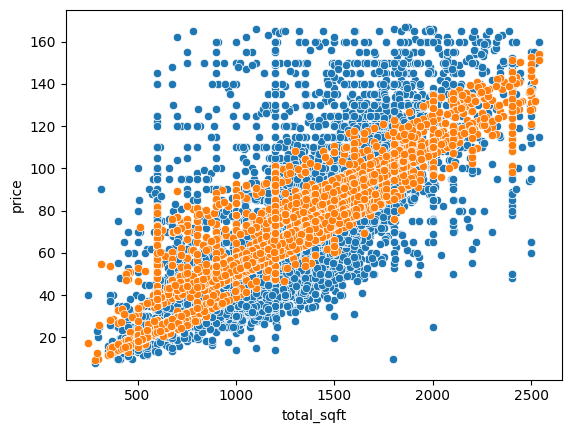

In [51]:
sns.scatterplot(x = xtrain["total_sqft"], y = ytrain)
sns.scatterplot(x = xtrain["total_sqft"], y = ypred)

<Axes: xlabel='bath', ylabel='price'>

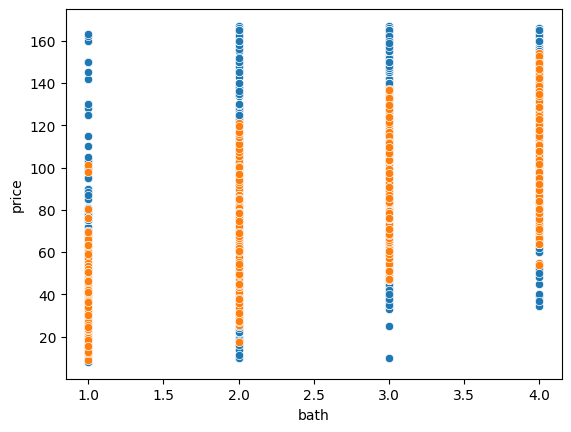

In [52]:
sns.scatterplot(x = xtrain["bath"], y = ytrain)
sns.scatterplot(x = xtrain["bath"], y = ypred)

<Axes: xlabel='balcony', ylabel='price'>

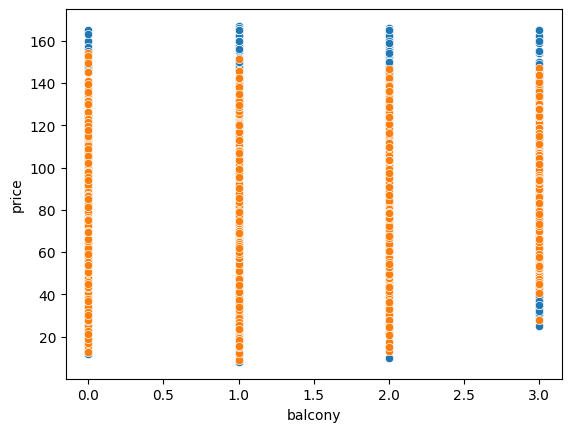

In [53]:
sns.scatterplot(x = xtrain["balcony"], y = ytrain)
sns.scatterplot(x = xtrain["balcony"], y = ypred)

<Axes: xlabel='bhk', ylabel='price'>

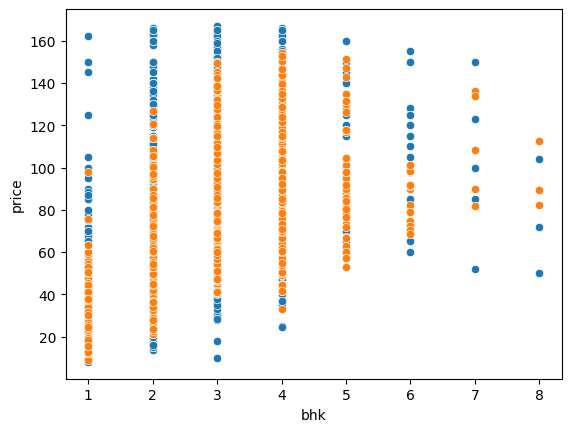

In [54]:
sns.scatterplot(x = xtrain["bhk"], y = ytrain)
sns.scatterplot(x = xtrain["bhk"], y = ypred)

__Here by comparing actual and predicted value of model we can say that the model prediction is good.__